In [40]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
# Set initial gas conditions
T_0 = 7500 # K - Initial temperature reaction
rho_0 = 0.0013 # kg/m³ - Initial density reaction

E_const = 0 # J/kg - Energy offset to match reference data if needed

# Set planet atmosphere
q = 'CO2:0.9556,N2:0.0270,Ar:0.0160,O2:0.0014' # Composition, mole fractions
mech = '/Users/xiaoxizhou/Downloads/su_26/adrian_surf/code/airNASA9ions.yaml' # NASA 9 no ions species mechanism
model_short = "Chemical-RTV"

# Select fixed variables for equilibrium calculations
# fixed_vars = 'HP'  # Enthalpy-Pressure
fixed_vars = 'UV'  # Internal Energy-Volume

print(f"Main mechanism: {mech}")

Main mechanism: /Users/xiaoxizhou/Downloads/su_26/adrian_surf/code/airNASA9ions.yaml


In [9]:
#%% Single case analysis
print(f"\nSingle point analysis:")

# Create a reactor for time evolution
gas_react = ct.Solution(mech)

# Obtain next of initial conditions from initial gas state
gas_react.X = q  # Set initial mole fractions
gas_react.TD = T_0, rho_0
v_0 = gas_react.v  # m³/kg - Initial specific volume (constant volume evolution)
P_0 = gas_react.P  # Pa - Initial pressure (constant pressure evolution)
e_0 = gas_react.u + E_const  # Initial specific internal energy (J/kg)
h_0 = gas_react.h + E_const  # Initial specific enthalpy (J/kg)
print(f"T_0 = {T_0} K, rho_0 = {rho_0} kg/m³", f"=> P_0 = {P_0/1000:.1f} kPa", f"e_0 = {e_0/1e6:.2f} MJ/kg", f"h_0 = {h_0/1e6:.2f} MJ/kg")



Single point analysis:
T_0 = 7500 K, rho_0 = 0.0013 kg/m³ => P_0 = 1.9 kPa e_0 = 0.01 MJ/kg h_0 = 1.44 MJ/kg


In [10]:
# Choose evolution type based on fixed_vars
if fixed_vars == 'HP':
    reactor = ct.ConstPressureReactor(gas_react)
    reactor_net = ct.ReactorNet([reactor])
    print(f"Reactor type: Constant Pressure Reactor (HP)")
    print(f"Initial enthalpy: {h_0/1e6:.2f} MJ/kg")
elif fixed_vars == 'UV':
    reactor = ct.IdealGasReactor(gas_react)
    reactor.volume = v_0  # Set initial volume for constant volume evolution
    reactor_net = ct.ReactorNet([reactor])
    print(f"Reactor type: Constant Volume Reactor (UV)")
    print(f"Initial internal energy: {e_0/1e6:.2f} MJ/kg")

Reactor type: Constant Volume Reactor (UV)
Initial internal energy: 0.01 MJ/kg


/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/4117993818.py:8: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas_react)


In [13]:
#  Calculate equilibrium reference state for comparison
gas_equilibrium = ct.Solution(mech)
gas_equilibrium.X = q

if fixed_vars == 'HP':
    gas_equilibrium.HP = h_0 - E_const, P_0  
    gas_equilibrium.equilibrate('HP')  # Equilibrate at constant H,P (enthalpy, pressure)
elif fixed_vars == 'UV':
    gas_equilibrium.UV = e_0, v_0
    gas_equilibrium.equilibrate('UV')  # Equilibrate at constant U,V (internal energy, volume)

T_equilibrium = gas_equilibrium.T # K - Equilibrium temperature
v_equilibrium = gas_equilibrium.v  # m³/kg - Equilibrium specific volume (constant volume evolution)
P_equilibrium = gas_equilibrium.P  # Pa - Equilibrium pressure (constant pressure evolution)
e_equilibrium = gas_equilibrium.u + E_const  # Equilibrium specific internal energy (J/kg)
h_equilibrium = gas_equilibrium.h + E_const  # Equilibrium specific enthalpy (J/kg)
gamma_equilibrium = 1 + gas_equilibrium.P / (gas_equilibrium.density * (gas_equilibrium.u + E_const))  # gamma* equilibrium

print(f"Equilibrium temperature (HP): {T_equilibrium:.1f} K")

Equilibrium temperature (HP): 2773.0 K


In [ ]:
t_end = 1e-2 * np.exp(2000/T_0) * (0.1/rho_0**1.5) # End time for simulation
dt = 1e-14 * np.exp(2000/T_0) * (0.1/rho_0**1.5) # Time step for simulation
n_points= int(20000) # Number of time points to store during time evolution of reaction
time = np.logspace(np.log10(dt), np.log10(t_end), n_points) # Logarithmically spaced time array, better captures fast initial transients

In [17]:
# Initialize arrays for storing results
TEMP = np.zeros(n_points)
PRESSURE = np.zeros(n_points)
DENSITY = np.zeros(n_points)
ENERGY = np.zeros(n_points)
ENTHALPY = np.zeros(n_points)

# Species tracking arrays (log10 of molar fractions)
log10_CO2 = np.zeros(n_points)
# log10_H2 = np.zeros(n_points)
log10_O2 = np.zeros(n_points)
log10_N2 = np.zeros(n_points)
log10_CO = np.zeros(n_points)
log10_NO = np.zeros(n_points)
log10_C = np.zeros(n_points)
log10_O = np.zeros(n_points)
# log10_H = np.zeros(n_points)
log10_N = np.zeros(n_points)

# Thermodynamic properties
cv_star = np.zeros(n_points)
gamma_star = np.zeros(n_points)

In [18]:
# Species indices for faster access
species_names = ['CO2', 'O2', 'N2', 'CO', 'NO', 'C', 'O', 'N']
species_indices = {}
for name in species_names:
    try:
        species_indices[name] = gas_react.species_index(name)
    except ValueError:
        species_indices[name] = None  # Species not found in mechanism

print("Starting time evolution...")
print(f"Initial conditions: T = {T_0} K, P = {P_0/1000:.1f} kPa")

Starting time evolution...
Initial conditions: T = 7500 K, P = 1.9 kPa


In [19]:
# Time evolution loop
for i in range(n_points):
    # Advance to current time
    reactor_net.advance(time[i])

    # Store thermodynamic properties
    TEMP[i] = reactor.thermo.T
    PRESSURE[i] = reactor.thermo.P
    DENSITY[i] = reactor.thermo.density
    ENERGY[i] = reactor.thermo.u + E_const
    ENTHALPY[i] = reactor.thermo.h + E_const
    
    # Compute cv^* = e/T (specific internal energy / temperature)
    cv_star[i] = ENERGY[i] / reactor.T
    
    # Compute gamma^* = 1 + P/(rho*e)
    gamma_star[i] = 1 + reactor.thermo.P / (reactor.thermo.density * ENERGY[i])
    
    # Get molar fractions and compute log10 values
    X = reactor.thermo.X  # Molar fractions
    
    # Store log10 of molar fractions (handle very small values)
    min_fraction = 1e-16  # Minimum fraction to avoid log(0)
    
    log10_CO2[i] = np.log10(max(X[species_indices['CO2']], min_fraction)) if species_indices['CO2'] is not None else -16
    # log10_H2[i] = np.log10(max(X[species_indices['H2']], min_fraction)) if species_indices['H2'] is not None else -16
    log10_O2[i] = np.log10(max(X[species_indices['O2']], min_fraction)) if species_indices['O2'] is not None else -16
    log10_N2[i] = np.log10(max(X[species_indices['N2']], min_fraction)) if species_indices['N2'] is not None else -16
    log10_CO[i] = np.log10(max(X[species_indices['CO']], min_fraction)) if species_indices['CO'] is not None else -16
    log10_NO[i] = np.log10(max(X[species_indices['NO']], min_fraction)) if species_indices['NO'] is not None else -16
    log10_C[i] = np.log10(max(X[species_indices['C']], min_fraction)) if species_indices['C'] is not None else -16
    log10_O[i] = np.log10(max(X[species_indices['O']], min_fraction)) if species_indices['O'] is not None else -16
    # log10_H[i] = np.log10(max(X[species_indices['H']], min_fraction)) if species_indices['H'] is not None else -16
    log10_N[i] = np.log10(max(X[species_indices['N']], min_fraction)) if species_indices['N'] is not None else -16

print("Time evolution completed!")

Time evolution completed!


/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/2656228097.py:7: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  TEMP[i] = reactor.thermo.T
/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/2656228097.py:8: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  PRESSURE[i] = reactor.thermo.P
/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/2656228097.py:9: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  DENSITY[i] = reactor.thermo.density
/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/2656228097.py:10: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  ENERGY[i] = reactor.thermo.u + E_const
/var/folders/zg/ww8l7gx92v137bxp8w7zv1_w0000gn/T/ipykernel_19916/2656228097.py:11: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Re

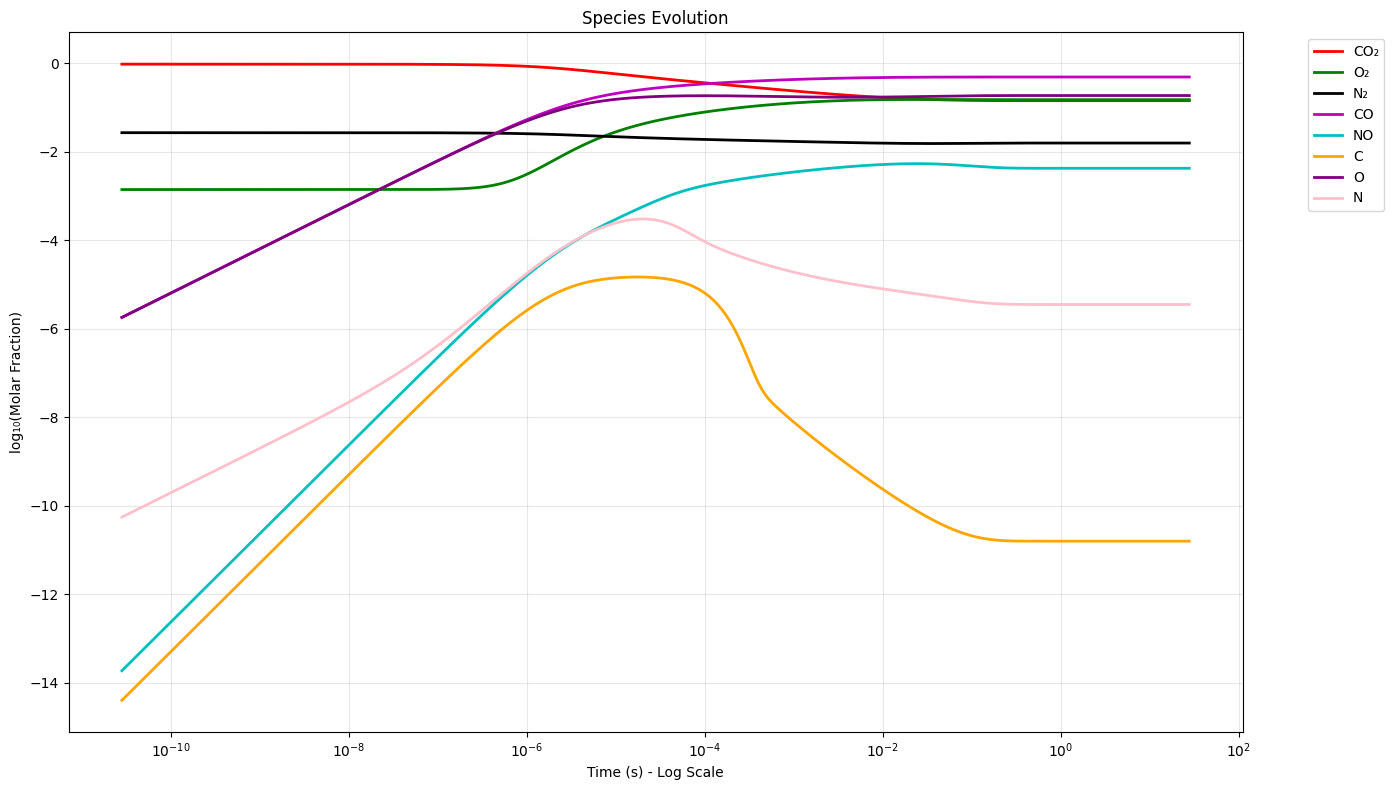

In [20]:
# Plot 1: Log10 molar fractions of species - use log time scale to see fast relaxation
plt.figure(figsize=(14, 8))
plt.semilogx(time, log10_CO2, 'r-', linewidth=2, label='CO₂')
# plt.semilogx(time, log10_H2, 'b-', linewidth=2, label='H₂')
plt.semilogx(time, log10_O2, 'g-', linewidth=2, label='O₂')
plt.semilogx(time, log10_N2, 'k-', linewidth=2, label='N₂')
plt.semilogx(time, log10_CO, 'm-', linewidth=2, label='CO')
plt.semilogx(time, log10_NO, 'c-', linewidth=2, label='NO')
plt.semilogx(time, log10_C, 'orange', linewidth=2, label='C')
plt.semilogx(time, log10_O, 'purple', linewidth=2, label='O')
# plt.semilogx(time, log10_H, 'brown', linewidth=2, label='H')
plt.semilogx(time, log10_N, 'pink', linewidth=2, label='N')
plt.xlabel('Time (s) - Log Scale')
plt.ylabel('log₁₀(Molar Fraction)')
plt.title(f'Species Evolution')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

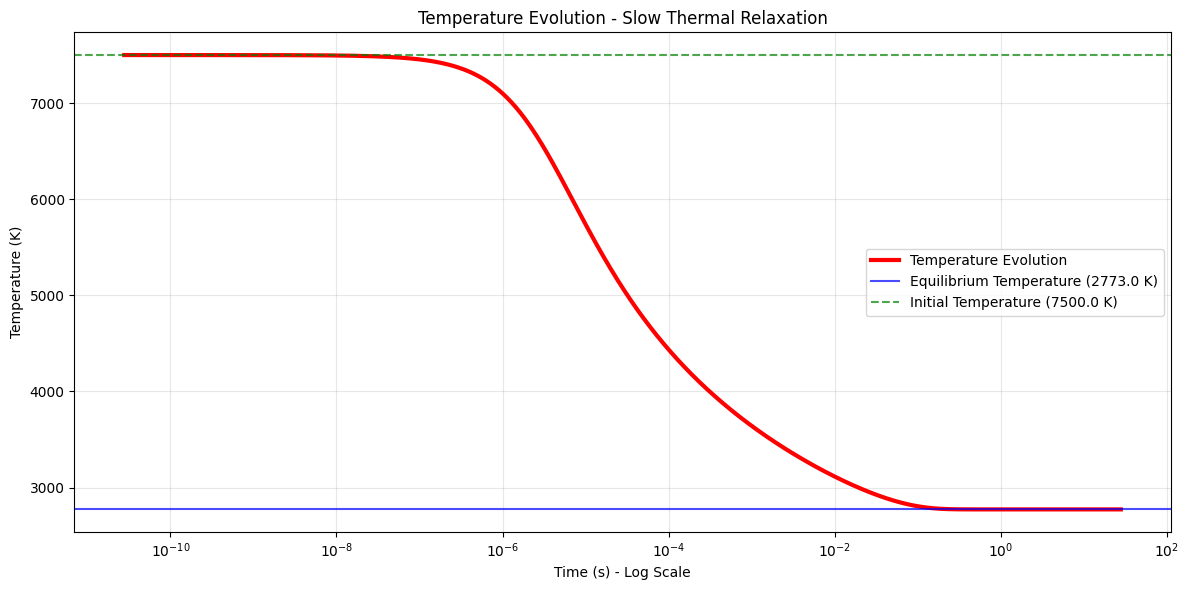

In [21]:
# Plot 2: Temperature evolution - showing slow thermal relaxation
plt.figure(figsize=(12, 6))
plt.semilogx(time, TEMP, 'r-', linewidth=3, label='Temperature Evolution')
plt.axhline(T_equilibrium, color='blue', linestyle='-', alpha=0.7, 
           label=f'Equilibrium Temperature ({T_equilibrium:.1f} K)')
plt.axhline(T_0, color='green', linestyle='--', alpha=0.7, 
           label=f'Initial Temperature ({T_0:.1f} K)')

plt.xlabel('Time (s) - Log Scale')
plt.ylabel('Temperature (K)')
plt.title('Temperature Evolution - Slow Thermal Relaxation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


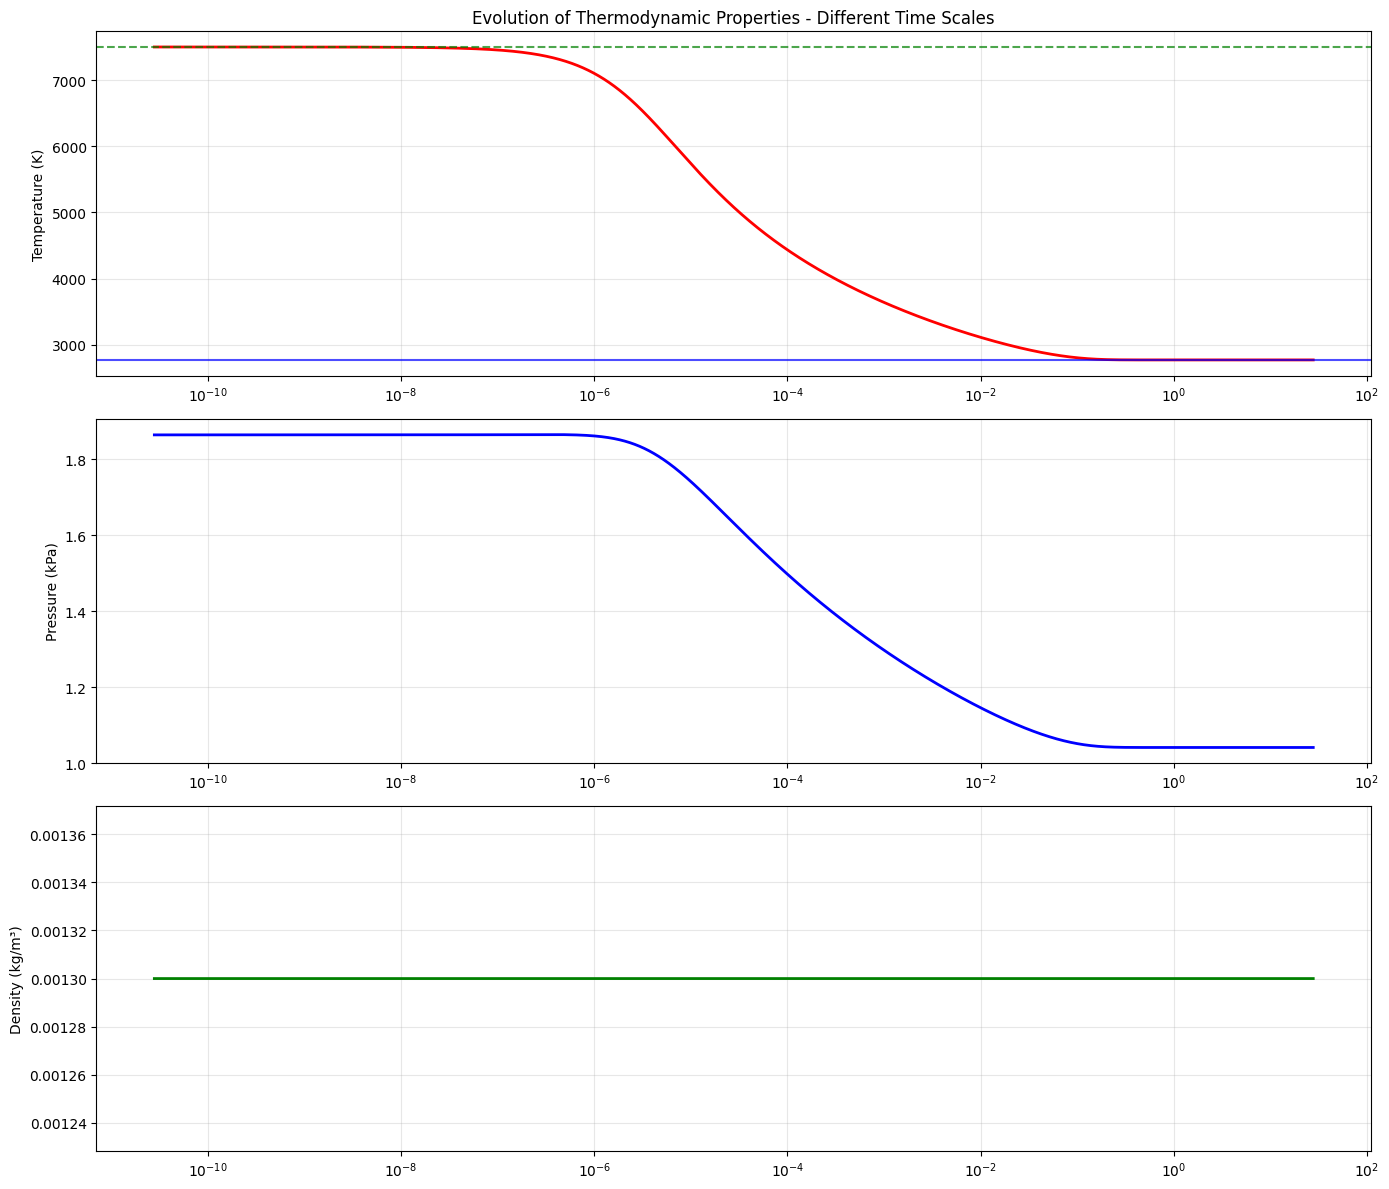


Final conditions:
Temperature: 2772.968737 K
Pressure: 1.041160 kPa
Density: 0.001300 kg/m³
Enthalpy: 0.811539 MJ/kg
Enthalpy change: 43.811939% (should be close to 0% for constant enthalpy)
Internal energy change: 0.005844% (should be close to 0% for constant energy)


In [22]:
# Plot 5: Combined thermodynamic properties - Log time scale
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Temperature
ax1.semilogx(time, TEMP, 'r-', linewidth=2)
ax1.axhline(T_0, color='green', linestyle='--', alpha=0.7, 
           label=f'Initial Temperature ({T_0:.1f} K)')
ax1.axhline(T_equilibrium, color='blue', linestyle='-', alpha=0.7, 
           label=f'Equilibrium Temperature ({T_equilibrium:.1f} K)')
ax1.set_ylabel('Temperature (K)')
ax1.set_title('Evolution of Thermodynamic Properties - Different Time Scales')
ax1.grid(True, alpha=0.3)

# Pressure
ax2.semilogx(time, PRESSURE/1000, 'b-', linewidth=2)  # Convert to kPa
ax2.set_ylabel('Pressure (kPa)')
ax2.grid(True, alpha=0.3)

# Density
ax3.semilogx(time, DENSITY, 'g-', linewidth=2)
ax3.set_ylabel('Density (kg/m³)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal conditions:")
print(f"Temperature: {TEMP[-1]:.6f} K")
print(f"Pressure: {PRESSURE[-1]/1000:.6f} kPa")
print(f"Density: {DENSITY[-1]:.6f} kg/m³")
print(f"Enthalpy: {ENTHALPY[-1]/1e6:.6f} MJ/kg")
enthalpy_change = abs(ENTHALPY[-1] - h_0) / h_0 * 100
print(f"Enthalpy change: {enthalpy_change:.6f}% (should be close to 0% for constant enthalpy)")
energy_change = abs(ENERGY[-1] - e_0) / e_0 * 100
print(f"Internal energy change: {energy_change:.6f}% (should be close to 0% for constant energy)")


In [42]:
# Save training data from Single Case Analysis to CSV and NPZ
print("\n" + "="*60)
print("SAVING TRAINING DATA")
print("="*60)

# Organize species data
species_names = ['CO2', 'O2', 'N2', 'CO', 'NO', 'C', 'O', 'N']
X_data_full = np.column_stack([
    np.exp(np.log(10) * log10_CO2),  # Convert log10 back to linear
    np.exp(np.log(10) * log10_O2),
    np.exp(np.log(10) * log10_N2),
    np.exp(np.log(10) * log10_CO),
    np.exp(np.log(10) * log10_NO),
    np.exp(np.log(10) * log10_C),
    np.exp(np.log(10) * log10_O),
    np.exp(np.log(10) * log10_N),
])

# Create log_time for NN input
log_time_full = np.log10(time)
X_input_full = log_time_full.reshape(-1, 1)

# Create Y_output (raw values)
Y_output_full = np.hstack([X_data_full, TEMP.reshape(-1,1), PRESSURE.reshape(-1,1)])

# Compute normalization stats (for normalizing the concentration of the data)
X_mean = X_input_full.mean(axis=0)
X_std = X_input_full.std(axis=0)

log10_X_data = np.log10(X_data_full)
log10_T_data = np.log10(TEMP).reshape(-1, 1)
log10_P_data = np.log10(PRESSURE).reshape(-1, 1)
Y_log_full = np.hstack([log10_X_data, log10_T_data, log10_P_data])

Y_mean = Y_log_full.mean(axis=0)
Y_std = Y_log_full.std(axis=0)

out_dir = os.getcwd()
npz_path = os.path.join(out_dir, 'training_data.npz')
csv_path = os.path.join(out_dir, 'training_data.csv')

# Save NPZ
col_names = species_names + ['T', 'P']
np.savez_compressed(
    npz_path,
    time=time,
    log_time=log_time_full,
    X_species=X_data_full,
    temperature=TEMP,
    pressure=PRESSURE,
    density=DENSITY,
    energy=ENERGY,
    X_input=X_input_full,
    Y_output=Y_output_full,
    Y_log=Y_log_full,
    X_mean=X_mean,
    X_std=X_std,
    Y_mean=Y_mean,
    Y_std=Y_std,
    species_names=np.array(species_names),
    output_columns=np.array(col_names),
    T_0=np.array([T_0]),
    rho_0=np.array([rho_0]),
    fixed_vars=np.array([fixed_vars]),
)
print(f"✓ Saved NPZ → {npz_path}")

# Save CSV
df = pd.DataFrame({
    'time': time,
    'log10_t': log_time_full,
    **{f'X_{name}': X_data_full[:, j] for j, name in enumerate(species_names)},
    **{f'log10_X_{name}': log10_X_data[:, j] for j, name in enumerate(species_names)},
    'T_K': TEMP,
    'P_Pa': PRESSURE,
    'rho_kgm3': DENSITY,
})
df.to_csv(csv_path, index=False, float_format='%.8e')
print(f"✓ Saved CSV → {csv_path}")

print(f"\nNormalisation stats (log10-space for targets):")
for i, name in enumerate(col_names):
    print(f"  {name:>5}: mean={Y_mean[i]:+7.3f}  std={Y_std[i]:.3f}")



SAVING TRAINING DATA
✓ Saved NPZ → /Users/xiaoxizhou/Downloads/su_26/adrian_surf/code/training_data.npz
✓ Saved CSV → /Users/xiaoxizhou/Downloads/su_26/adrian_surf/code/training_data.csv

Normalisation stats (log10-space for targets):
    CO2: mean= -0.393  std=0.352
     O2: mean= -1.738  std=0.917
     N2: mean= -1.686  std=0.103
     CO: mean= -1.595  std=1.684
     NO: mean= -5.174  std=3.562
      C: mean= -8.932  std=2.611
      O: mean= -1.804  std=1.536
      N: mean= -5.933  std=1.823
      T: mean= +3.681  std=0.183
      P: mean= +3.168  std=0.107
